# Step 1 — EDA + User Contention 偵測

**目標**：了解四段耗時分佈 + 偵測同 device 短時間多單的 contention

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
print(f"Loaded {len(df):,} orders, {df['device_id'].nunique()} devices")


Loaded 30,000 orders, 2000 devices


## Part A — EDA: 四段耗時分佈

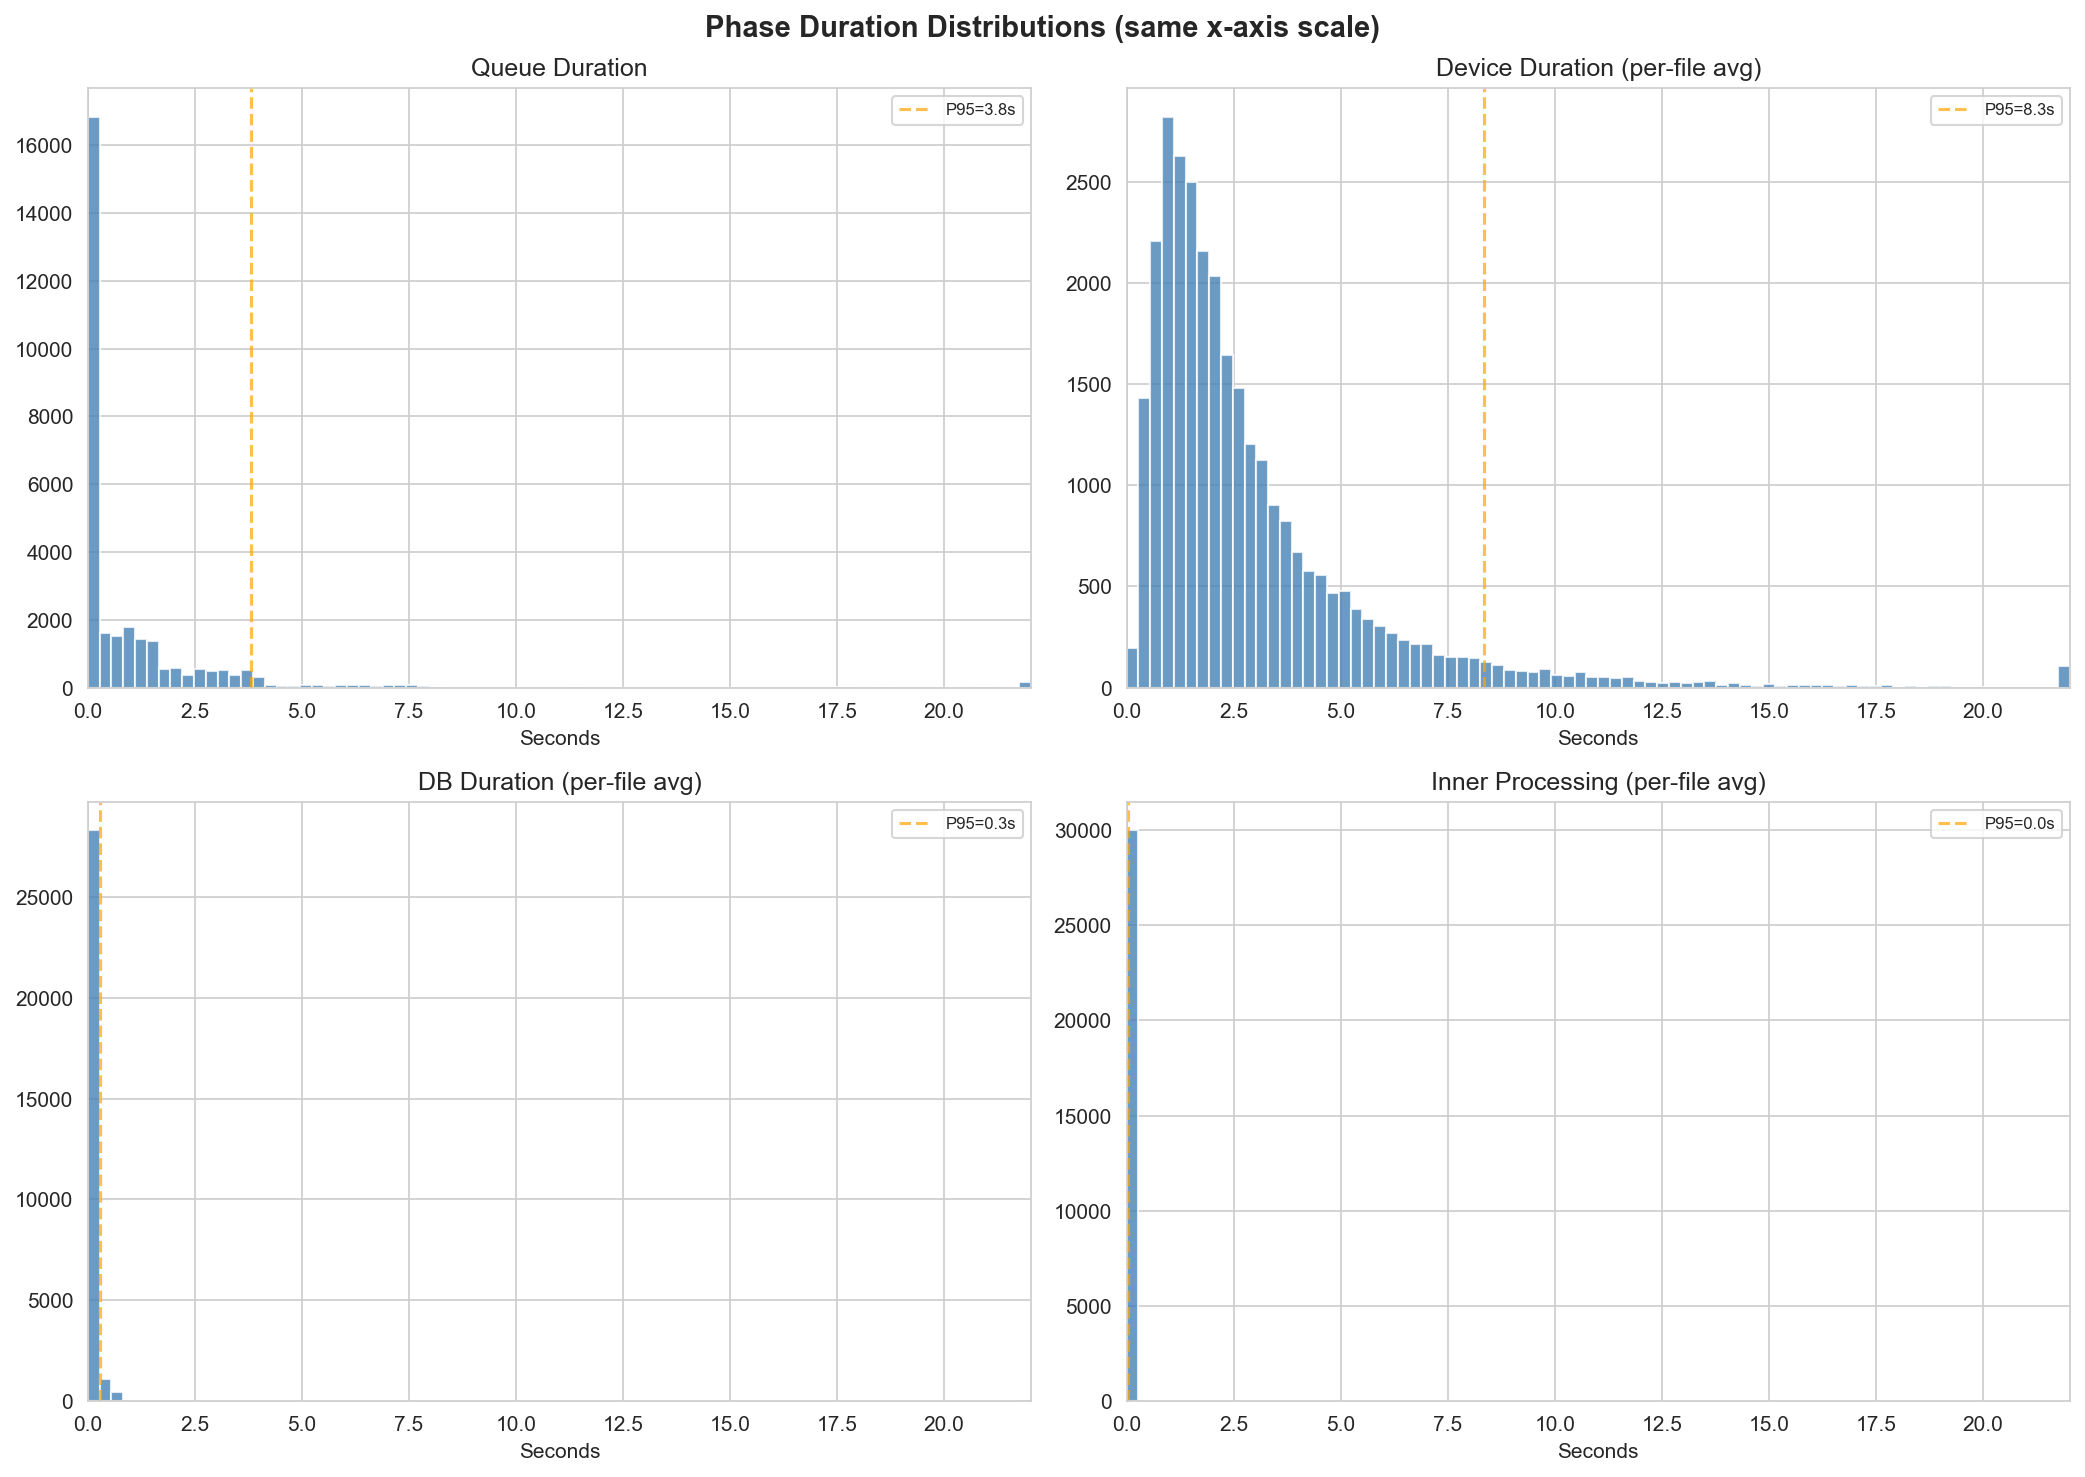

Queue Duration: P50=0.0, P75=1.3, P95=3.8, P99=7.7, max=65.2
Device Duration (per-file avg): P50=2.1, P75=3.6, P95=8.3, P99=14.7, max=500.79
DB Duration (per-file avg): P50=0.0, P75=0.1, P95=0.3, P99=0.7, max=1198.78
Inner Processing (per-file avg): P50=0.0, P75=0.0, P95=0.0, P99=0.1, max=0.1487


In [3]:
# 4-panel phase histograms (shared x-axis for comparison)
phase_cols = {
    'queue_duration_seconds': 'Queue Duration',
    'device_duration_avg_seconds': 'Device Duration (per-file avg)',
    'db_duration_avg_seconds': 'DB Duration (per-file avg)',
    'inner_processing_duration_avg_seconds': 'Inner Processing (per-file avg)',
}

# Use a shared x-axis upper bound across all 4 phases
shared_xmax = max(df[col].quantile(0.99) * 1.5 for col in phase_cols)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (col, title) in enumerate(phase_cols.items()):
    ax = axes[idx // 2][idx % 2]
    data = df[col].clip(upper=shared_xmax)
    ax.hist(data, bins=80, range=(0, shared_xmax), color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Seconds')
    ax.set_xlim(0, shared_xmax)
    pcts = df[col].quantile([0.5, 0.95, 0.99])
    ax.axvline(x=pcts[0.95], color='orange', linestyle='--', alpha=0.7, label=f'P95={pcts[0.95]:.1f}s')
    ax.legend(fontsize=8)

plt.suptitle('Phase Duration Distributions (same x-axis scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_phase_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print percentiles
for col, title in phase_cols.items():
    pcts = df[col].quantile([0.5, 0.75, 0.95, 0.99])
    print(f"{title}: P50={pcts[0.5]:.1f}, P75={pcts[0.75]:.1f}, P95={pcts[0.95]:.1f}, P99={pcts[0.99]:.1f}, max={df[col].max()}")

file_count: P25=51, P50=122, P75=301, P95=967, P99=2748, max=10088


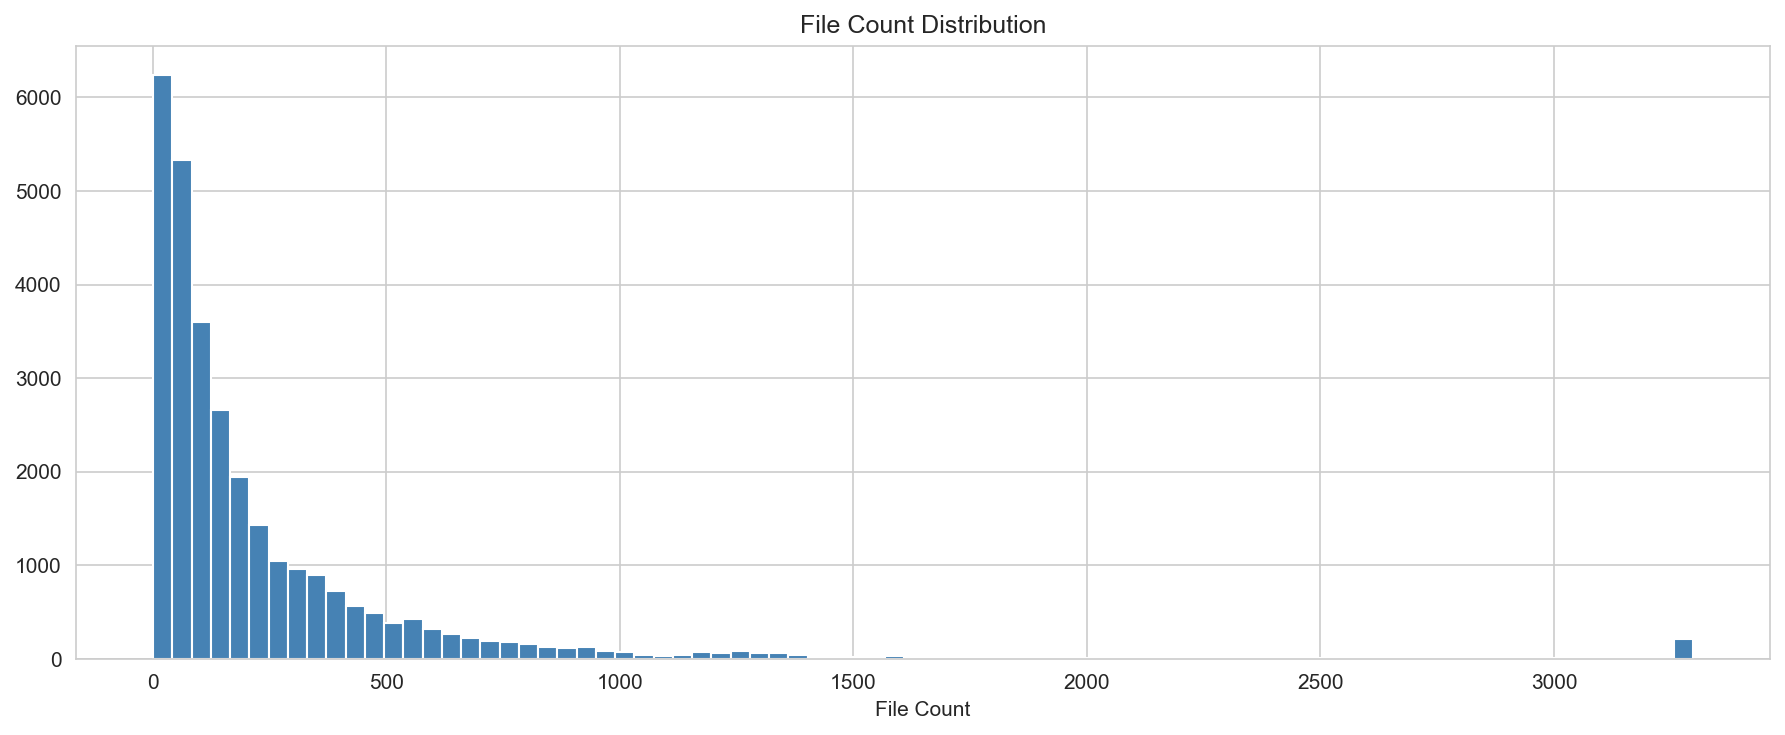

In [4]:
# file_count distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['file_count'].clip(upper=df['file_count'].quantile(0.99)*1.2), bins=80,
        color='steelblue', edgecolor='white')
ax.set_title('File Count Distribution')
ax.set_xlabel('File Count')
pcts = df['file_count'].quantile([0.25, 0.5, 0.75, 0.95, 0.99])
print(f"file_count: P25={pcts[0.25]:.0f}, P50={pcts[0.5]:.0f}, P75={pcts[0.75]:.0f}, "
      f"P95={pcts[0.95]:.0f}, P99={pcts[0.99]:.0f}, max={df['file_count'].max()}")
plt.tight_layout()
plt.show()


=== File Count Bin Statistics ===
           Orders  Orders (%)  Unique Devices  Devices (%)  File Count (med)  File Count (mean)  Total Dur med(s)  Total Dur P95(s)  Total Dur Std(s)  File Dur med(min)  Device Dur med(s)  Device Dur P95(s)  DB Dur med(s)  Queue Dur med(s)
fc_group                                                                                                                                                                                                                                       
<100        13325        44.4             907         45.4              45.0              47.77              32.1            125.78            569.31                0.4               2.06               8.35            0.0               0.0
100-1000    15235        50.8            1050         52.5             241.0             310.89             145.0            837.63           2635.22                2.2               2.06               8.30            0.0               0.0
1000-2

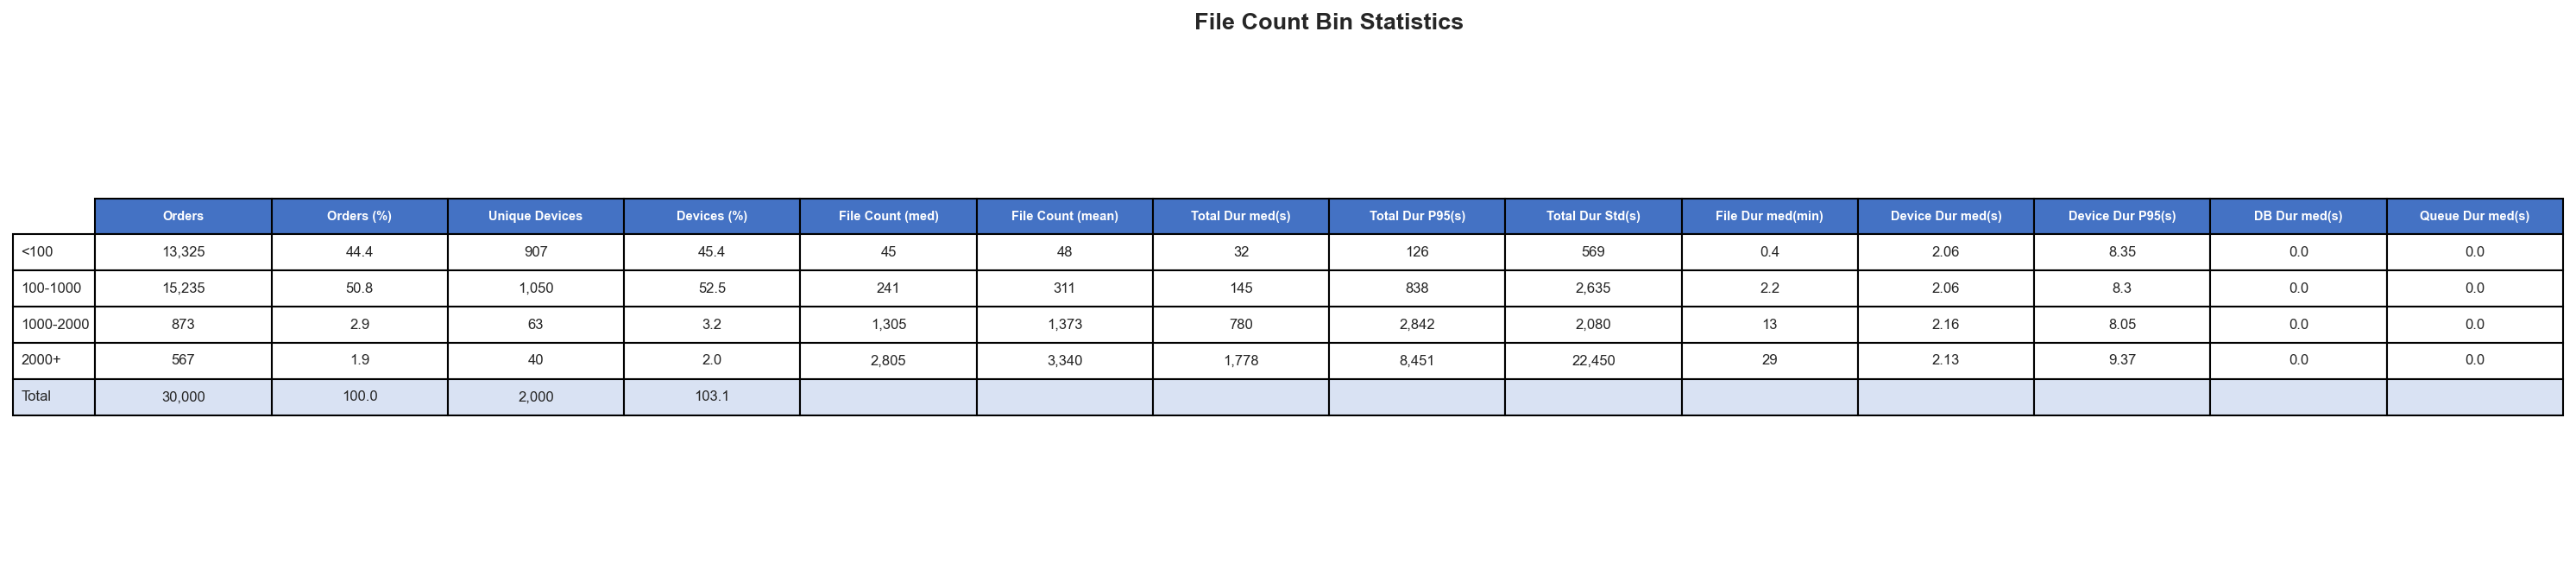

In [5]:
# File count bin statistics
df['fc_group'] = pd.cut(df['file_count'], bins=FILE_COUNT_BINS, labels=FILE_COUNT_LABELS, right=True)

total_orders = len(df)
total_devices = df['device_id'].nunique()

bin_stats = df.groupby('fc_group', observed=True).agg(
    orders=('order_id', 'count'),
    unique_devices=('device_id', 'nunique'),
    file_count_median=('file_count', 'median'),
    file_count_mean=('file_count', 'mean'),
    total_dur_median=('total_duration_seconds', 'median'),
    total_dur_p95=('total_duration_seconds', lambda x: x.quantile(0.95)),
    total_dur_std=('total_duration_seconds', 'std'),
    total_file_dur_median=('total_file_duration_minutes', 'median'),
    device_dur_median=('device_duration_avg_seconds', 'median'),
    device_dur_p95=('device_duration_avg_seconds', lambda x: x.quantile(0.95)),
    db_dur_median=('db_duration_avg_seconds', 'median'),
    queue_dur_median=('queue_duration_seconds', 'median'),
).round(2)

bin_stats.insert(1, 'orders_pct', (bin_stats['orders'] / total_orders * 100).round(1))
bin_stats.insert(3, 'devices_pct', (bin_stats['unique_devices'] / total_devices * 100).round(1))

bin_stats.columns = [
    'Orders', 'Orders (%)', 'Unique Devices', 'Devices (%)',
    'File Count (med)', 'File Count (mean)',
    'Total Dur med(s)', 'Total Dur P95(s)', 'Total Dur Std(s)',
    'File Dur med(min)', 'Device Dur med(s)', 'Device Dur P95(s)',
    'DB Dur med(s)', 'Queue Dur med(s)',
]

print("=== File Count Bin Statistics ===")
print(bin_stats.to_string())

# Add total row (only counts/percentages; stats columns left blank)
total_dict = {c: '' for c in bin_stats.columns}
total_dict['Orders'] = total_orders
total_dict['Orders (%)'] = 100.0
total_dict['Unique Devices'] = total_devices
total_dict['Devices (%)'] = round(bin_stats['Devices (%)'].sum(), 1)
total = pd.DataFrame([total_dict], index=['Total'])

bin_stats_full = pd.concat([bin_stats, total])

# Export as CSV
bin_stats_full.to_csv(str(REPORTS_DIR / 'step1_bin_statistics.csv'))
print(f"\nSaved: reports/step1_bin_statistics.csv")

# Render as table image
fig, ax = plt.subplots(figsize=(20, max(3, len(bin_stats_full) * 0.6 + 1.5)))
ax.axis('off')
ax.set_title('File Count Bin Statistics', fontsize=13, fontweight='bold', pad=15)

cell_text = []
for idx, row in bin_stats_full.iterrows():
    cell_text.append([f'{v:,.0f}' if isinstance(v, (int, float)) and abs(v) > 10 and c not in ('Orders (%)', 'Devices (%)')
                      else f'{v}' for v, c in zip(row.values, bin_stats_full.columns)])

tbl = ax.table(cellText=cell_text, colLabels=bin_stats_full.columns.tolist(),
               rowLabels=bin_stats_full.index.tolist(),
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)

for j in range(len(bin_stats_full.columns)):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold', fontsize=7)
# Total row highlight
for j in range(-1, len(bin_stats_full.columns)):
    tbl[len(bin_stats_full), j].set_facecolor('#D9E2F3')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_bin_statistics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

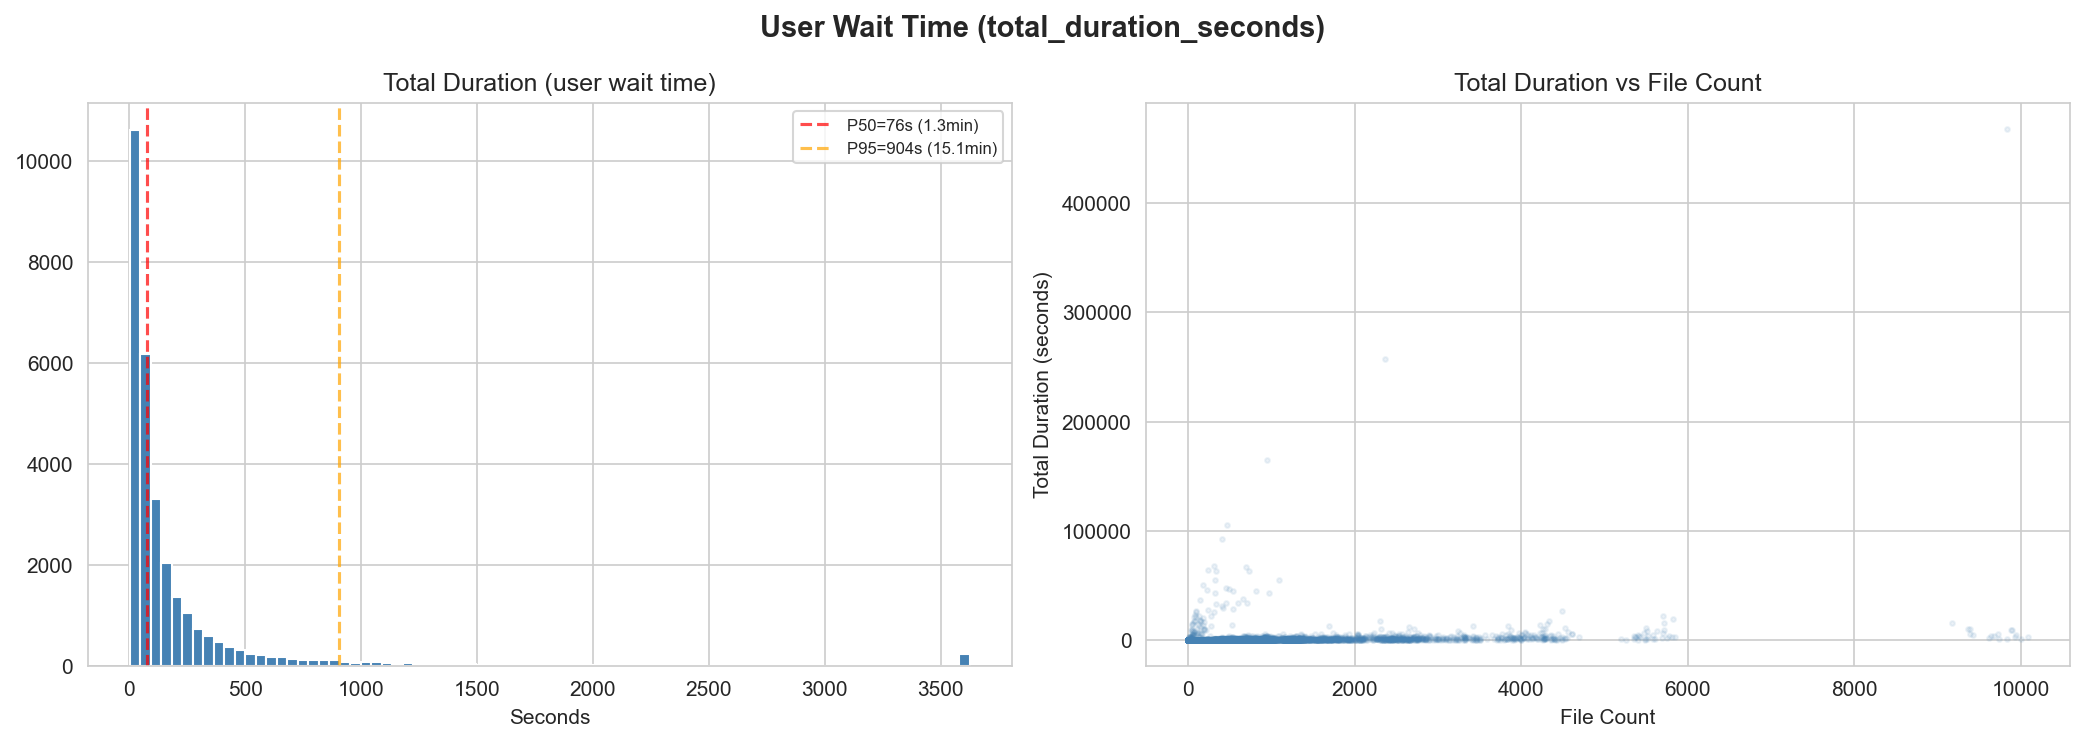

total_duration_seconds: P50=76s (1.3min), P75=194s (3.2min), P95=904s (15.1min), P99=3021s (50.4min)

30分鐘內完成: 29,380 (97.9%)
超過1小時: 235 (0.8%)


In [6]:
# User wait time: total_duration_seconds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total_duration_seconds distribution
ax = axes[0]
clip_val = df['total_duration_seconds'].quantile(0.99) * 1.2
ax.hist(df['total_duration_seconds'].clip(upper=clip_val), bins=80, color='steelblue', edgecolor='white')
pcts = df['total_duration_seconds'].quantile([0.5, 0.95])
ax.axvline(x=pcts[0.5], color='red', linestyle='--', alpha=0.7, label=f'P50={pcts[0.5]:.0f}s ({pcts[0.5]/60:.1f}min)')
ax.axvline(x=pcts[0.95], color='orange', linestyle='--', alpha=0.7, label=f'P95={pcts[0.95]:.0f}s ({pcts[0.95]/60:.1f}min)')
ax.set_title('Total Duration (user wait time)')
ax.set_xlabel('Seconds')
ax.legend(fontsize=8)

# Right: total_duration vs file_count
ax = axes[1]
ax.scatter(df['file_count'], df['total_duration_seconds'], alpha=0.1, s=5, c='steelblue')
ax.set_title('Total Duration vs File Count')
ax.set_xlabel('File Count')
ax.set_ylabel('Total Duration (seconds)')

plt.suptitle('User Wait Time (total_duration_seconds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_user_wait_time.png', dpi=150, bbox_inches='tight')
plt.show()

pcts = df['total_duration_seconds'].quantile([0.5, 0.75, 0.95, 0.99])
print(f"total_duration_seconds: P50={pcts[0.5]:.0f}s ({pcts[0.5]/60:.1f}min), "
      f"P75={pcts[0.75]:.0f}s ({pcts[0.75]/60:.1f}min), "
      f"P95={pcts[0.95]:.0f}s ({pcts[0.95]/60:.1f}min), "
      f"P99={pcts[0.99]:.0f}s ({pcts[0.99]/60:.1f}min)")
print(f"\n30分鐘內完成: {(df['total_duration_seconds'] <= 1800).sum():,} ({100*(df['total_duration_seconds'] <= 1800).mean():.1f}%)")
print(f"超過1小時: {(df['total_duration_seconds'] > 3600).sum():,} ({100*(df['total_duration_seconds'] > 3600).mean():.1f}%)")


In [7]:
# Device Model Order Distribution → CSV
model_counts = df['device_mode_name'].fillna('(null)').value_counts().reset_index()
model_counts.columns = ['Device Model', 'Order Count']
model_counts['%'] = (model_counts['Order Count'] / model_counts['Order Count'].sum() * 100).round(1)
total_row = pd.DataFrame([{'Device Model': 'Total', 'Order Count': model_counts['Order Count'].sum(), '%': 100.0}])
model_table = pd.concat([model_counts, total_row], ignore_index=True)

model_table.to_csv(str(REPORTS_DIR / 'step1_device_model_order_dist.csv'), index=False)
print(f"Saved: reports/step1_device_model_order_dist.csv")
print(f"Device models: {df['device_mode_name'].nunique()} types + {df['device_mode_name'].isnull().mean()*100:.1f}% null")
print(model_table.head(10).to_string(index=False))
if len(model_table) > 11:
    print(f"... ({len(model_table)-1} models total)")


Saved: reports/step1_device_model_order_dist.csv
Device models: 50 types + 16.6% null
Device Model  Order Count    %
      (null)         4986 16.6
     SER-006          752  2.5
     TYP-042          696  2.3
     SER-025          629  2.1
     SER-030          621  2.1
     SER-024          604  2.0
     SER-047          603  2.0
     SER-029          580  1.9
     EQP-050          561  1.9
     MDL-039          556  1.9
... (51 models total)


## 時間趨勢

每日 total_duration P50/P95 + 訂單量趨勢。觀察系統效能是否在劣化。

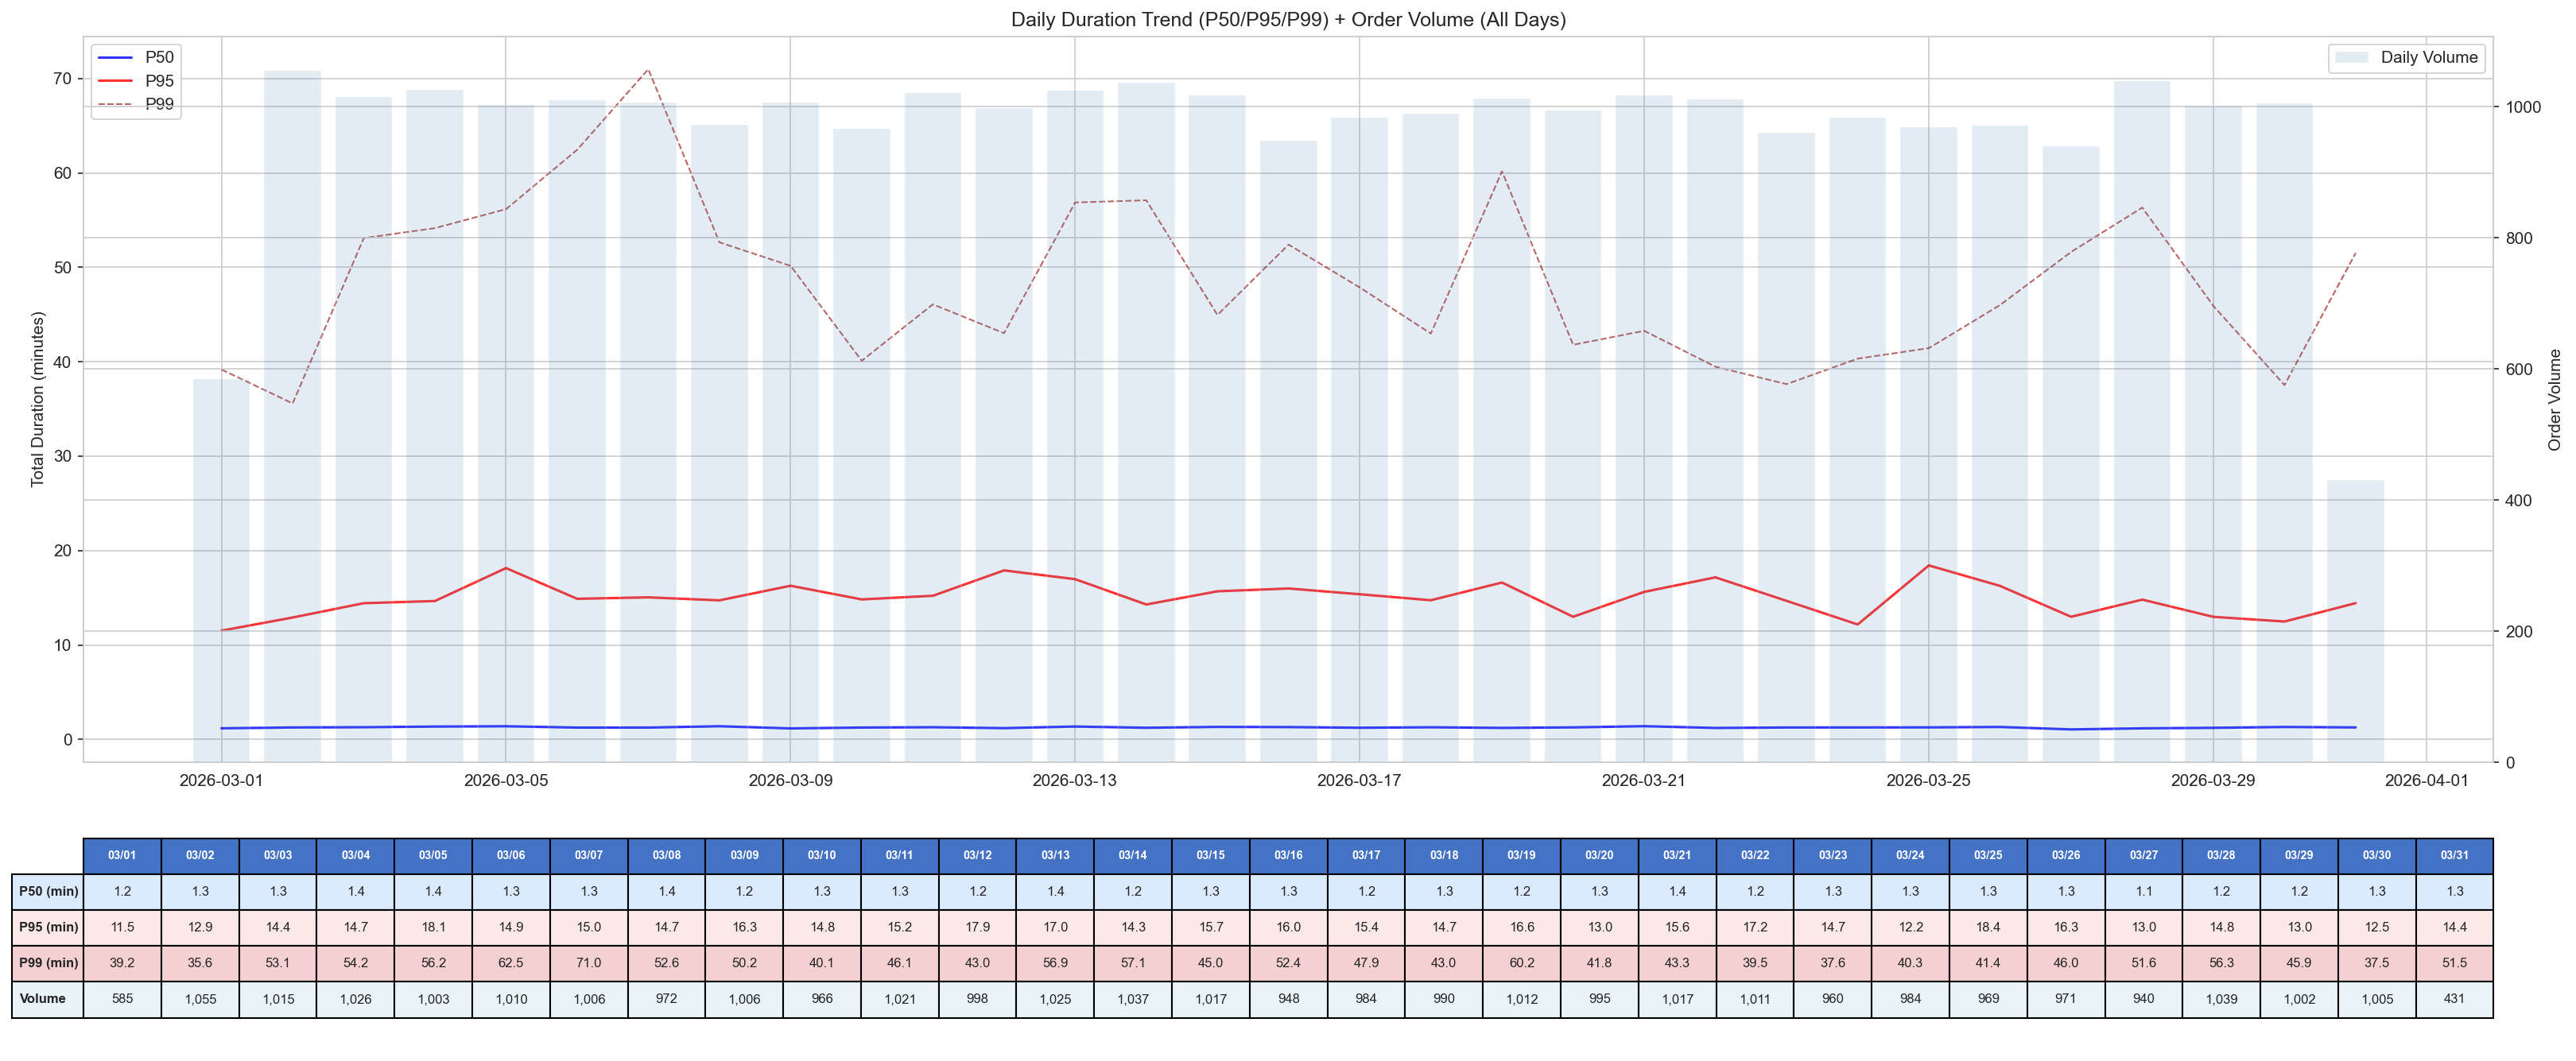

P50 trend: first week avg=1.3min, last week avg=1.2min, change=-3.9% → 穩定


In [8]:
# Daily duration trend
df['date'] = df['order_created_at'].dt.date
daily = df.groupby('date').agg(
    p50=('total_duration_seconds', 'median'),
    p95=('total_duration_seconds', lambda x: x.quantile(0.95)),
    p99=('total_duration_seconds', lambda x: x.quantile(0.99)),
    volume=('order_id', 'count'),
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

# Convert to minutes
for col in ['p50', 'p95', 'p99']:
    daily[col] = daily[col] / 60

if TREND_LAST_N_DAYS > 0:
    cutoff = daily['date'].max() - pd.Timedelta(days=TREND_LAST_N_DAYS - 1)
    daily_plot = daily[daily['date'] >= cutoff].copy()
    trend_label = f'Last {TREND_LAST_N_DAYS} Days'
else:
    daily_plot = daily.copy()
    trend_label = 'All Days'

fig, (ax1, ax_tbl) = plt.subplots(2, 1, figsize=(max(14, len(daily_plot) * 0.7), 9),
                                   gridspec_kw={'height_ratios': [3, 1]})

# --- Top: trend lines + volume bars ---
ax1.plot(daily_plot['date'], daily_plot['p50'], 'b-', linewidth=1.5, label='P50', alpha=0.8)
ax1.plot(daily_plot['date'], daily_plot['p95'], 'r-', linewidth=1.5, label='P95', alpha=0.8)
ax1.plot(daily_plot['date'], daily_plot['p99'], 'darkred', linewidth=1, linestyle='--', label='P99', alpha=0.6)
ax1.set_ylabel('Total Duration (minutes)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(daily_plot['date'], daily_plot['volume'], alpha=0.15, color='steelblue', width=0.8, label='Daily Volume')
ax2.set_ylabel('Order Volume')
ax2.legend(loc='upper right')

ax1.set_title(f'Daily Duration Trend (P50/P95/P99) + Order Volume ({trend_label})')

# --- Bottom: summary table ---
date_labels = [d.strftime('%m/%d') for d in daily_plot['date']]
cell_text = [
    [f'{v:.1f}' for v in daily_plot['p50']],
    [f'{v:.1f}' for v in daily_plot['p95']],
    [f'{v:.1f}' for v in daily_plot['p99']],
    [f'{v:,}' for v in daily_plot['volume']],
]
row_labels = ['P50 (min)', 'P95 (min)', 'P99 (min)', 'Volume']
row_colors = ['#dbeafe', '#fde8e8', '#f5d0d0', '#e8f4f8']

ax_tbl.axis('off')
tbl = ax_tbl.table(cellText=cell_text, rowLabels=row_labels, colLabels=date_labels,
                    cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)
# Style header row
for j in range(len(date_labels)):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold', fontsize=7)
# Style row labels + row background
for r, color in enumerate(row_colors):
    tbl[r + 1, -1].set_facecolor(color)
    tbl[r + 1, -1].set_text_props(fontweight='bold')
    for j in range(len(date_labels)):
        tbl[r + 1, j].set_facecolor(color)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_duration_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Trend direction (always use full data)
if len(daily) >= 7:
    first_week = daily.head(7)['p50'].mean()
    last_week = daily.tail(7)['p50'].mean()
    change = (last_week - first_week) / first_week * 100 if first_week > 0 else 0
    direction = '\u2191 \u4e0a\u5347' if change > 10 else '\u2193 \u4e0b\u964d' if change < -10 else '\u2192 \u7a69\u5b9a'
    print(f"P50 trend: first week avg={first_week:.1f}min, last week avg={last_week:.1f}min, change={change:+.1f}% {direction}")

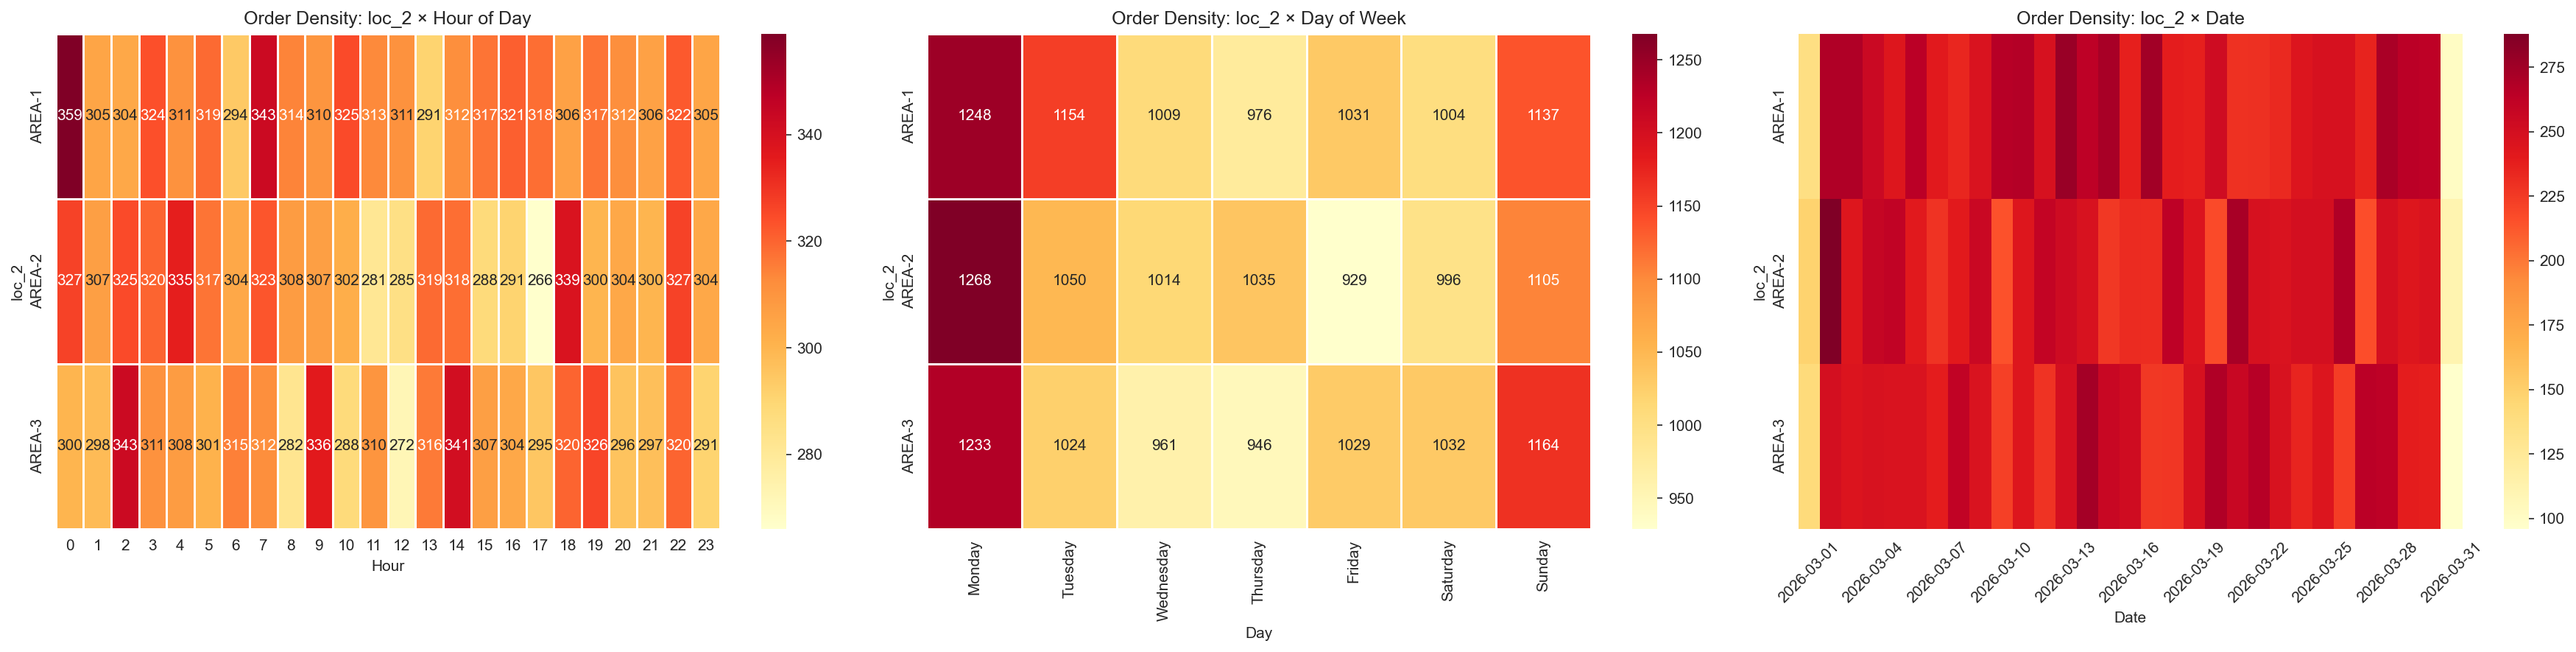

Peak hour: 7:00 (1,310 orders)
Daily volume: min=431, max=1055, mean=968


In [9]:
# Usage heatmap: loc_2 × hour / day-of-week / date
df['hour'] = df['order_created_at'].dt.hour
df['date'] = df['order_created_at'].dt.date

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Left: loc_2 × hour
loc2_hour = df.dropna(subset=['loc_2']).groupby(['loc_2', 'hour']).size().unstack(fill_value=0)
sns.heatmap(loc2_hour, cmap='YlOrRd', annot=True, fmt='d', ax=axes[0], linewidths=0.5)
axes[0].set_title('Order Density: loc_2 × Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('loc_2')

# Middle: loc_2 × day-of-week
df['dow'] = df['order_created_at'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
loc2_dow = df.dropna(subset=['loc_2']).groupby(['loc_2', 'dow']).size().unstack(fill_value=0)
loc2_dow = loc2_dow.reindex(columns=[d for d in dow_order if d in loc2_dow.columns], fill_value=0)
sns.heatmap(loc2_dow, cmap='YlOrRd', annot=True, fmt='d', ax=axes[1], linewidths=0.5)
axes[1].set_title('Order Density: loc_2 × Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('loc_2')

# Right: loc_2 × date (daily volume)
loc2_date = df.dropna(subset=['loc_2']).groupby(['loc_2', 'date']).size().unstack(fill_value=0)
sns.heatmap(loc2_date, cmap='YlOrRd', ax=axes[2], linewidths=0,
            xticklabels=max(1, len(loc2_date.columns)//10))  # show every Nth date
axes[2].set_title('Order Density: loc_2 × Date')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('loc_2')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_usage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

total_by_hour = df.groupby('hour').size()
peak_hour = total_by_hour.idxmax()
print(f"Peak hour: {peak_hour}:00 ({total_by_hour[peak_hour]:,} orders)")

daily_total = df.groupby('date').size()
print(f"Daily volume: min={daily_total.min()}, max={daily_total.max()}, mean={daily_total.mean():.0f}")


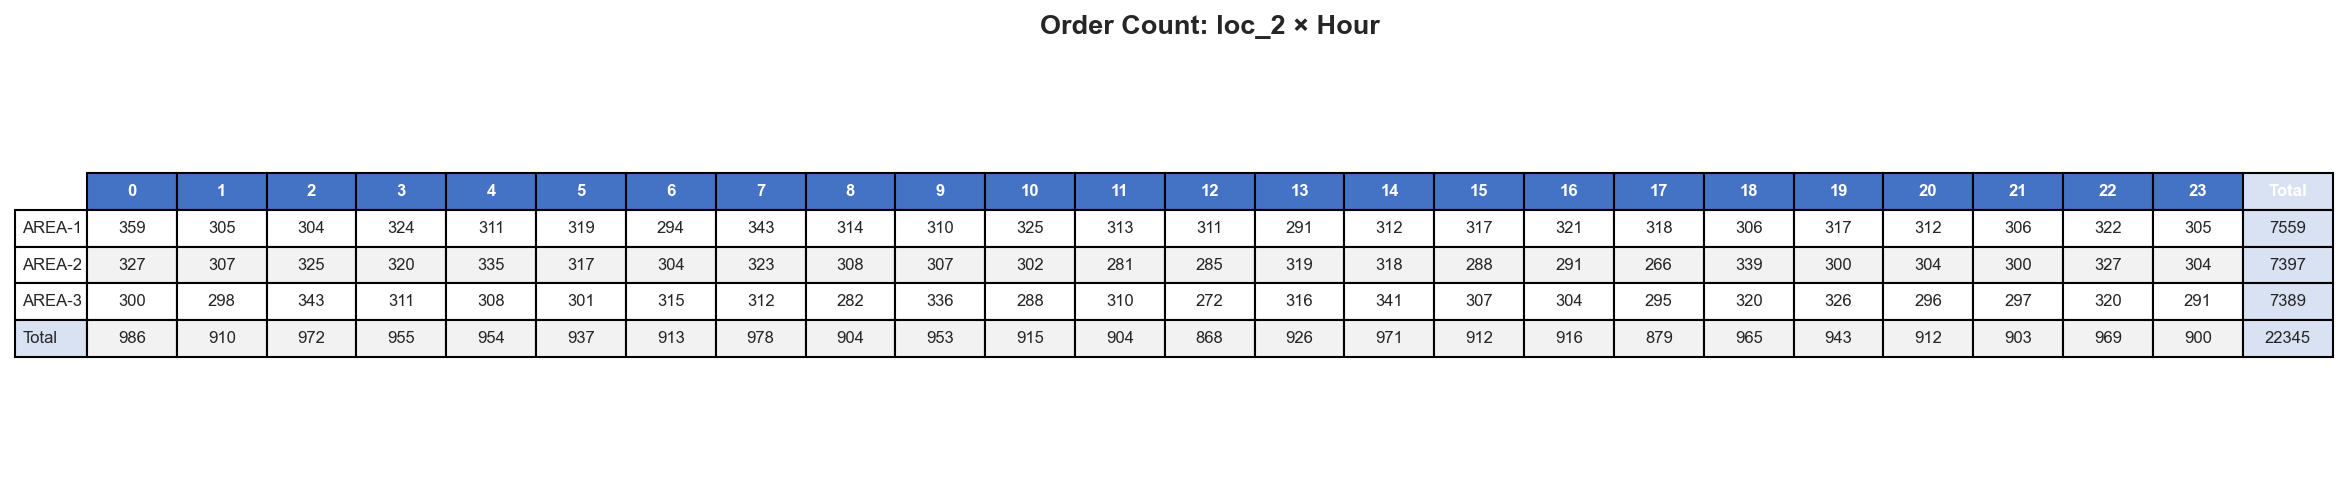

Saved: ../reports/step1_table_loc2_hour.png


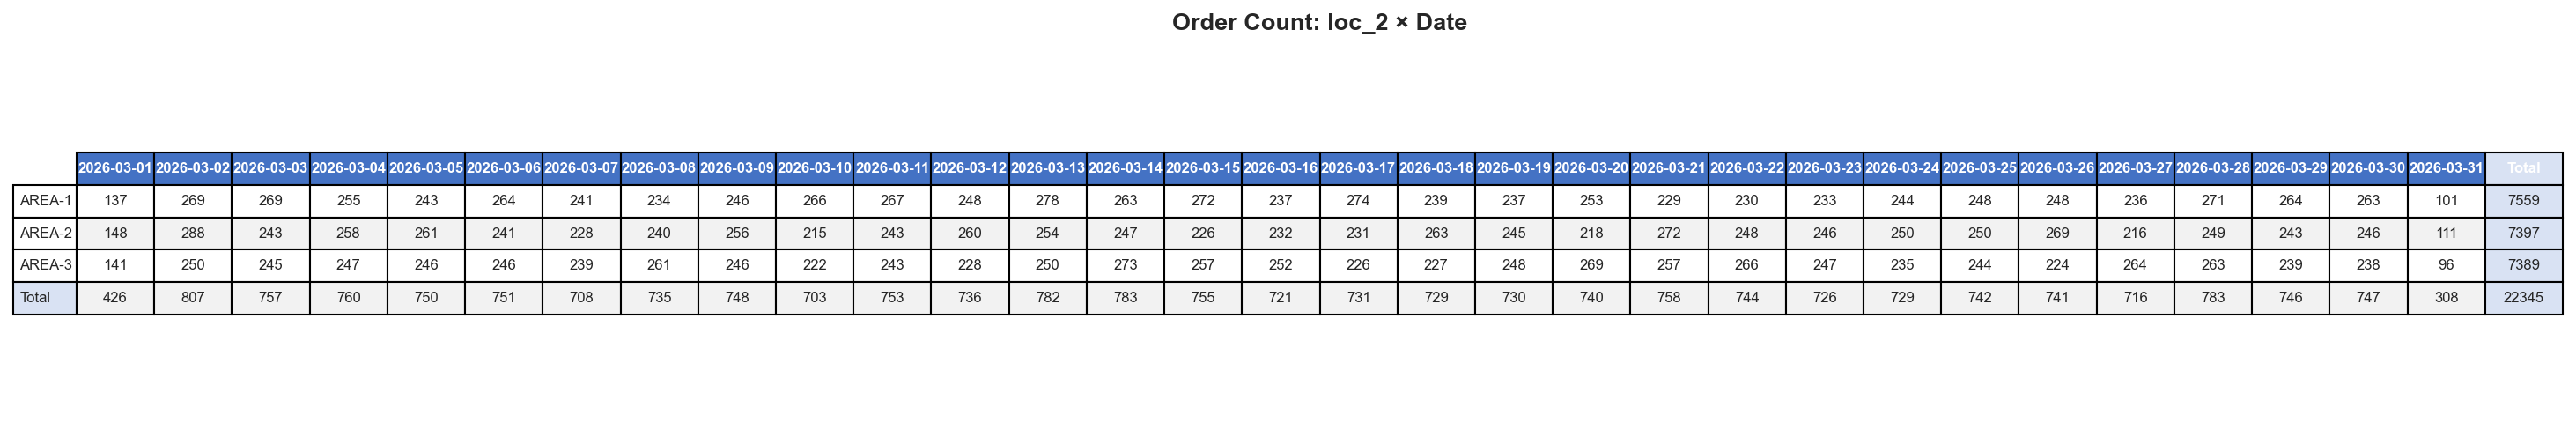

Saved: ../reports/step1_table_loc2_date.png


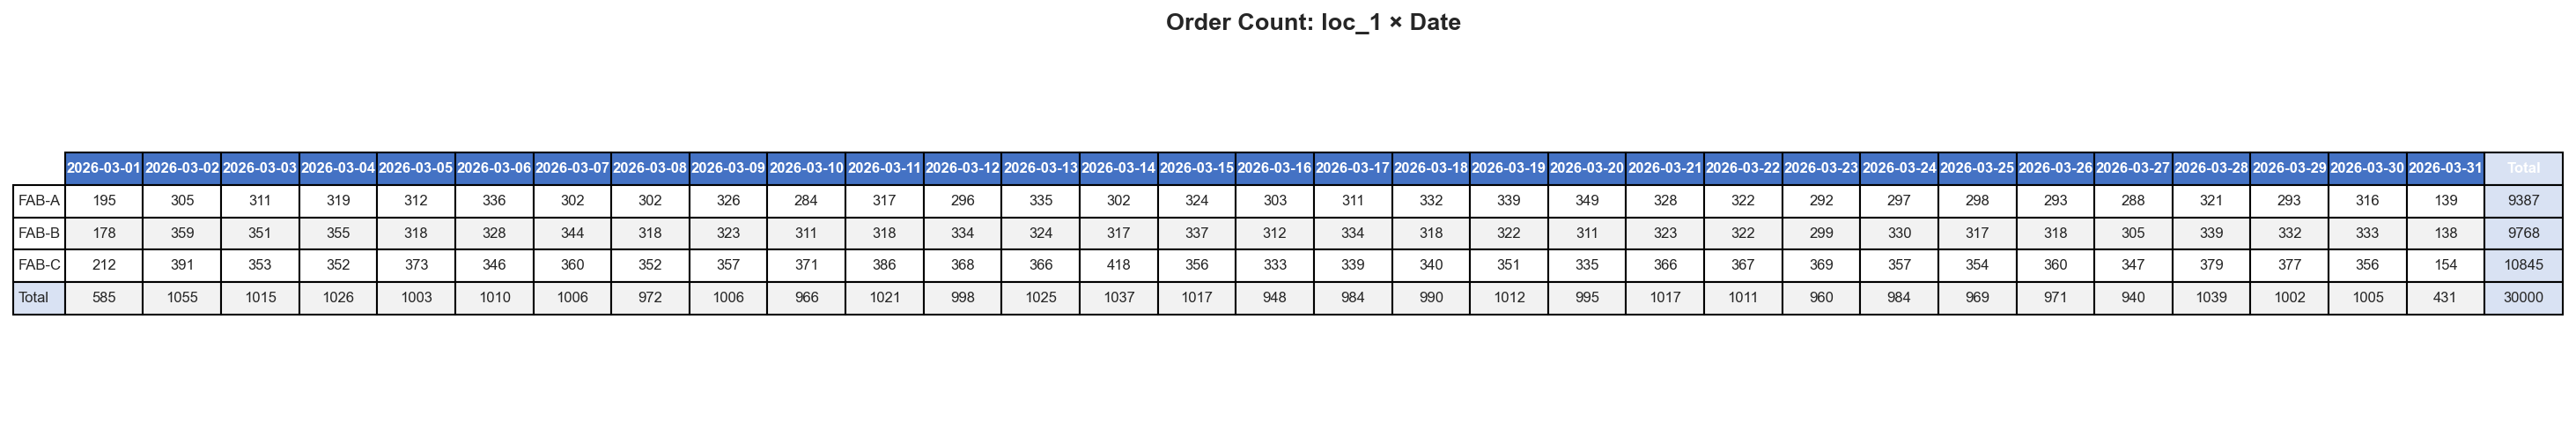

Saved: ../reports/step1_table_loc1_date.png
Saved: reports/step1_usage_tables.txt


In [10]:
# Crosstab tables (比 heatmap 更清楚)

# Build tables
loc2_date_table = df.dropna(subset=['loc_2']).groupby(['loc_2', 'date']).size().unstack(fill_value=0)
loc2_date_table['Total'] = loc2_date_table.sum(axis=1)
daily_total = loc2_date_table.sum(axis=0)
daily_total.name = 'Total'
loc2_date_table = pd.concat([loc2_date_table, daily_total.to_frame().T])

loc2_hour_table = df.dropna(subset=['loc_2']).groupby(['loc_2', 'hour']).size().unstack(fill_value=0)
loc2_hour_table['Total'] = loc2_hour_table.sum(axis=1)
hourly_total = loc2_hour_table.sum(axis=0)
hourly_total.name = 'Total'
loc2_hour_table = pd.concat([loc2_hour_table, hourly_total.to_frame().T])

loc1_date_table = df.groupby(['loc_1', 'date']).size().unstack(fill_value=0)
loc1_date_table['Total'] = loc1_date_table.sum(axis=1)
daily_total_1 = loc1_date_table.sum(axis=0)
daily_total_1.name = 'Total'
loc1_date_table = pd.concat([loc1_date_table, daily_total_1.to_frame().T])

# Render as table images
def table_to_image(table, title, filepath, date_cols=False):
    col_labels = [str(c).split(' ')[0] if date_cols and c != 'Total' else str(c) for c in table.columns]
    n_cols = len(col_labels)
    n_rows = len(table)
    
    fig_w = max(8, n_cols * 0.55 + 2)
    fig_h = max(2, n_rows * 0.45 + 1.5)
    
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    
    cell_text = table.values.astype(int).astype(str).tolist()
    row_labels = [str(r) for r in table.index]
    
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, rowLabels=row_labels,
                   cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    
    # Style: header row
    for j in range(n_cols):
        tbl[0, j].set_facecolor('#4472C4')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    # Style: Total column
    for r in range(n_rows + 1):
        tbl[r, n_cols - 1].set_facecolor('#D9E2F3')
    # Style: Total row
    for j in range(-1, n_cols):
        tbl[n_rows, j].set_facecolor('#D9E2F3')
    # Style: alternating row colors
    for r in range(1, n_rows + 1):
        for j in range(n_cols):
            if r % 2 == 0 and j != n_cols - 1:
                tbl[r, j].set_facecolor('#F2F2F2')
    
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {filepath}")

table_to_image(loc2_hour_table, 'Order Count: loc_2 × Hour', 
               str(REPORTS_DIR / 'step1_table_loc2_hour.png'))

table_to_image(loc2_date_table, 'Order Count: loc_2 × Date',
               str(REPORTS_DIR / 'step1_table_loc2_date.png'), date_cols=True)

table_to_image(loc1_date_table, 'Order Count: loc_1 × Date',
               str(REPORTS_DIR / 'step1_table_loc1_date.png'), date_cols=True)

# Also export as text
with open(str(REPORTS_DIR / 'step1_usage_tables.txt'), 'w') as f:
    f.write("=== Order Count: loc_2 × Date ===\n")
    f.write(loc2_date_table.to_string())
    f.write("\n\n=== Order Count: loc_2 × Hour ===\n")
    f.write(loc2_hour_table.to_string())
    f.write("\n\n=== Order Count: loc_1 × Date ===\n")
    f.write(loc1_date_table.to_string())
print(f"Saved: reports/step1_usage_tables.txt")


## Part B — Contention Detection

同 device 在 `[t, t + WINDOW]` 內有 `>= MIN_ORDERS` 筆 order → contention

Contention orders: 1 / 30,000 (0.0%)
Devices with contention: 1


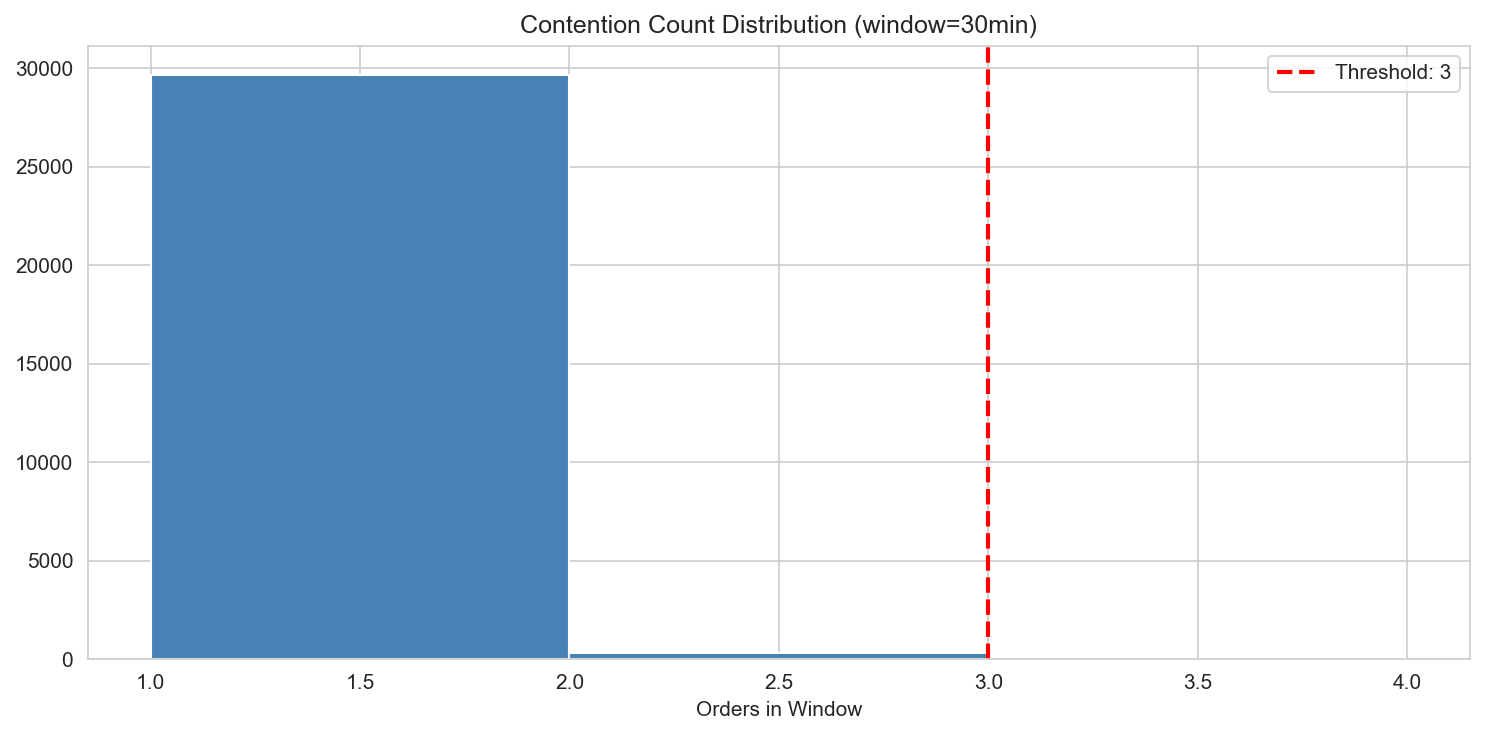

In [11]:
# Contention detection
df = df.sort_values(['device_id', 'order_created_at']).reset_index(drop=True)

def detect_contention(group):
    times = group['order_created_at'].values
    counts = []
    for i, t in enumerate(times):
        window_end = t + np.timedelta64(CONTENTION_WINDOW_MINUTES, 'm')
        count = ((times >= t) & (times <= window_end)).sum()
        counts.append(count)
    return pd.Series(counts, index=group.index)

df['contention_count'] = df.groupby('device_id', group_keys=False).apply(detect_contention)
df['is_user_anomaly'] = df['contention_count'] >= CONTENTION_MIN_ORDERS

contention = df[df['is_user_anomaly']]
print(f"Contention orders: {len(contention):,} / {len(df):,} ({100*len(contention)/len(df):.1f}%)")
print(f"Devices with contention: {contention['device_id'].nunique()}")

# Histogram of contention count
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['contention_count'], bins=range(1, df['contention_count'].max()+2),
        color='steelblue', edgecolor='white')
ax.axvline(x=CONTENTION_MIN_ORDERS, color='red', linestyle='--', linewidth=2,
           label=f'Threshold: {CONTENTION_MIN_ORDERS}')
ax.set_title(f'Contention Count Distribution (window={CONTENTION_WINDOW_MINUTES}min)')
ax.set_xlabel('Orders in Window')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step1_contention_count.png', dpi=150)
plt.show()


## Part C — Uplift Validation

**關鍵問題**：contention 是否真的造成 device_duration 偏高？
計算 per-device uplift = contention orders 的 device_duration median / non-contention median

Devices with both contention and normal orders: 1

Uplift distribution (contention_device_dur / normal_device_dur):
  P25=0.37, P50=0.37, P75=0.37, mean=0.37


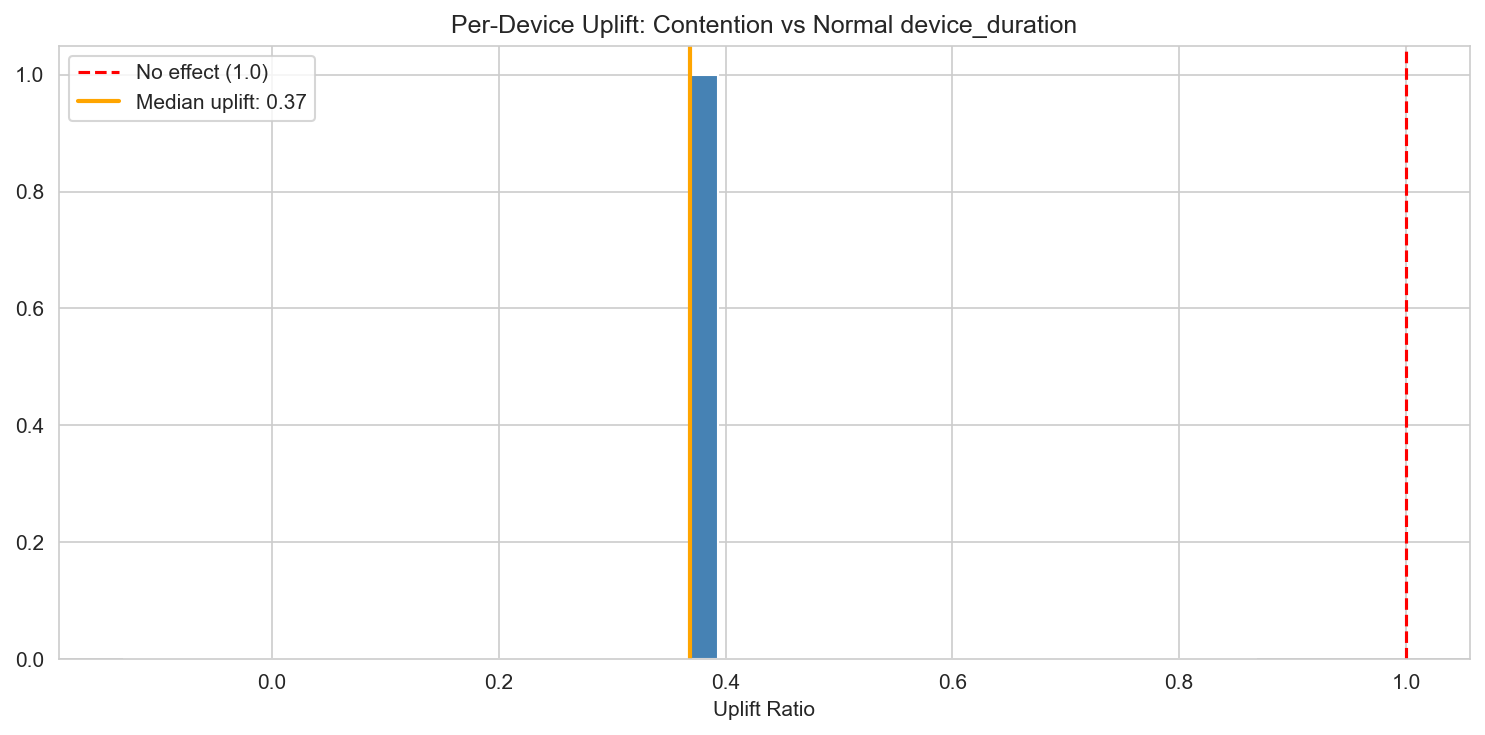


ℹ️  Contention 無明顯影響 (uplift=0.37x)
   → 建議調整參數（縮小 window 或提高 min_orders）
   → 或跳過 Layer 1b（將所有 is_user_anomaly 設為 False）


In [12]:
# Per-device uplift validation
devices_with_both = df.groupby('device_id')['is_user_anomaly'].agg(['sum', 'count'])
devices_with_both = devices_with_both[(devices_with_both['sum'] > 0) &
                                      (devices_with_both['sum'] < devices_with_both['count'])]
valid_devices = devices_with_both.index

if len(valid_devices) == 0:
    print("⚠️  沒有 device 同時有 contention 和 non-contention orders")
    print("   → 無法計算 uplift，考慮調整 CONTENTION_WINDOW_MINUTES 或 CONTENTION_MIN_ORDERS")
    uplift_median = 1.0
else:
    uplifts = []
    for dev in valid_devices:
        dev_data = df[df['device_id'] == dev]
        cont_med = dev_data.loc[dev_data['is_user_anomaly'], 'device_duration_avg_seconds'].median()
        norm_med = dev_data.loc[~dev_data['is_user_anomaly'], 'device_duration_avg_seconds'].median()
        if norm_med > 0:
            uplifts.append({'device_id': dev, 'uplift': cont_med / norm_med,
                           'cont_median': cont_med, 'norm_median': norm_med})

    uplift_df = pd.DataFrame(uplifts)
    uplift_median = uplift_df['uplift'].median()

    print(f"Devices with both contention and normal orders: {len(uplift_df)}")
    print(f"\nUplift distribution (contention_device_dur / normal_device_dur):")
    print(f"  P25={uplift_df['uplift'].quantile(0.25):.2f}, "
          f"P50={uplift_df['uplift'].median():.2f}, "
          f"P75={uplift_df['uplift'].quantile(0.75):.2f}, "
          f"mean={uplift_df['uplift'].mean():.2f}")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(uplift_df['uplift'], bins=40, color='steelblue', edgecolor='white')
    ax.axvline(x=1.0, color='red', linestyle='--', label='No effect (1.0)')
    ax.axvline(x=uplift_median, color='orange', linestyle='-', linewidth=2,
               label=f'Median uplift: {uplift_median:.2f}')
    ax.set_title('Per-Device Uplift: Contention vs Normal device_duration')
    ax.set_xlabel('Uplift Ratio')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'step1_uplift.png', dpi=150)
    plt.show()

# Verdict
print("\n" + "=" * 60)
if uplift_median > 1.3:
    print(f"✅ Contention 造成 device_duration 偏高 (uplift={uplift_median:.2f}x)")
    print(f"   → Layer 1b contention 偵測有效，保留標記")
elif uplift_median > 1.1:
    print(f"⚠️  Contention 有輕微影響 (uplift={uplift_median:.2f}x)")
    print(f"   → 可保留標記，但影響不大")
else:
    print(f"ℹ️  Contention 無明顯影響 (uplift={uplift_median:.2f}x)")
    print(f"   → 建議調整參數（縮小 window 或提高 min_orders）")
    print(f"   → 或跳過 Layer 1b（將所有 is_user_anomaly 設為 False）")
print("=" * 60)


## 匯出

In [13]:
# Export
user_flags = df[['order_id', 'is_user_anomaly']].copy()
user_flags.to_csv('../data/user_anomaly_flags.csv', index=False)
print(f"Exported: data/user_anomaly_flags.csv ({user_flags['is_user_anomaly'].sum():,} contention orders)")

print(f"\n=== Step 1 Summary ===")
print(f"Total orders: {len(df):,}")
print(f"Contention: {df['is_user_anomaly'].sum():,} ({100*df['is_user_anomaly'].mean():.1f}%)")
print(f"Params: window={CONTENTION_WINDOW_MINUTES}min, min_orders={CONTENTION_MIN_ORDERS}")
print(f"Uplift median: {uplift_median:.2f}x")


Exported: data/user_anomaly_flags.csv (1 contention orders)

=== Step 1 Summary ===
Total orders: 30,000
Contention: 1 (0.0%)
Params: window=30min, min_orders=3
Uplift median: 0.37x


In [14]:
# Export summary to reports/
summary = []
summary.append("=" * 60)
summary.append("Step 1 — EDA + User Contention")
summary.append("=" * 60)
summary.append(f"\nTotal orders: {len(df):,}  （分析的訂單總數）")
summary.append(f"Contention: {df['is_user_anomaly'].sum():,} ({100*df['is_user_anomaly'].mean():.1f}%)")
summary.append(f"  （同 device 在 {CONTENTION_WINDOW_MINUTES} 分鐘內有 ≥{CONTENTION_MIN_ORDERS} 筆訂單的 orders）")
summary.append(f"Uplift median: {uplift_median:.2f}x")
summary.append(f"  （contention 訂單的 device_duration 相對同 device 正常訂單的倍率，>1.3 表示 contention 確實造成變慢）")
if uplift_median > 1.3:
    summary.append(f"Verdict: Contention 有影響 → 這些訂單的 device 端因多單搶佔而變慢")
elif uplift_median > 1.1:
    summary.append(f"Verdict: Contention 輕微影響")
else:
    summary.append(f"Verdict: Contention 無明顯影響 → 同 device 多單並未造成 device 端變慢")

summary.append(f"\nPhase Percentiles:  （各階段的單檔平均耗時分佈）")
for col, title in phase_cols.items():
    pcts = df[col].quantile([0.5, 0.95, 0.99])
    summary.append(f"  {title}: P50={pcts[0.5]:.0f}s, P95={pcts[0.95]:.0f}s, P99={pcts[0.99]:.0f}s")

summary.append(f"\nDevice models: {df['device_mode_name'].nunique()} types + {df['device_mode_name'].isnull().mean()*100:.1f}% null")
summary.append(f"  （設備型號數量，null 表示該 device 未填寫型號）")
summary.append(f"Peak hour: {peak_hour}:00  （訂單最多的小時）")

with open(str(REPORTS_DIR / 'step1_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step1_summary.txt")


Saved: reports/step1_summary.txt
